## Install Libraries (Colab)

In [253]:
!pip install scikit-learn matplotlib seaborn pandas

In [254]:
DATA_PATH = "/content/question_paper_10000 - Question Paper Data.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42
MAX_FEATURES = 3000

## Import Libraries

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Load RACE Dataset

In [256]:
df = pd.read_csv(
    "/content/question_paper_10000 - Question Paper Data.csv",
    engine="python",
    quotechar='"',
    on_bad_lines="skip"
)

## Testing Data

In [257]:
df.sample(10)

,YEAR,SECTION,QUESTION_NUMBER,QUESTION_TEXT,QUESTION_TYPE,MARKS,DIFFICULTY_LABEL,TOPIC,ANSWER_TEXT
4182,2013,Section B (Python),4a,Write Python functions to PUSH and POP element...,Short Answer,2.0,medium,Python Stack Programs,"stack=[]\ndef PUSH(s,x): s.append(x)\ndef POP(..."
1465,2012,Section A (C++),2e,What is the address stored in pointer p? int a...,Very Short Answer,1.0,easy,C++ Basics - Pointers and Arrays,Output: 30 (p points to arr[2] which is 30)
2991,2012,Section B (Python),4e,Differentiate between class variables and inst...,Short Answer,2.0,medium,Python OOP - Class Variables and Instance Vari...,"Class variable: shared by all objects (e.g., c..."
9036,2016,Section C,6e,What is a MAC address? How is it different fro...,Short Answer,2.0,medium,Networking - Protocols,MAC address: hardware address burned into the ...
4888,2022,Section B,1h,Write a Python function for bubble sort on a l...,Short Answer,3.0,hard,Python - Sorting Algorithms,def bubbleSort(a):\n n=len(a)\n for i in...
4936,2020,Section B (Python),6h,Write a Python function to insert a new studen...,Short Answer,2.0,medium,Python MySQL Connectivity,"def insertStudent(rno,name,marks):\n cur.ex..."
9086,2017,Section C,4g,What is cloud computing? Name two service mode...,Short Answer,2.0,medium,Internet and Web Technologies,Cloud computing delivers computing services ov...
8976,2022,Section E,3d,What is cloud computing? Name two service mode...,Short Answer,2.0,medium,Internet and Web Technologies,Cloud computing delivers computing services ov...
3536,2020,Section B (Python),6d,Rewrite the following Python code removing all...,Short Answer,2.0,medium,Python Basics - Syntax Errors,Errors: (1) Missing colon after def square(n) ...
7488,2017,Section C,5b,Write a SQL query to display all records from ...,Very Short Answer,1.0,easy,SQL - SELECT with WHERE,SELECT * FROM EMPLOYEES WHERE Name LIKE 'A%';


In [258]:
df.isna().sum()

,0
YEAR,0
SECTION,0
QUESTION_NUMBER,0
QUESTION_TEXT,0
QUESTION_TYPE,0
MARKS,0
DIFFICULTY_LABEL,0
TOPIC,0
ANSWER_TEXT,0


In [259]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10000, 9)

Columns: Index(['YEAR', 'SECTION', 'QUESTION_NUMBER', 'QUESTION_TEXT', 'QUESTION_TYPE',
       'MARKS', 'DIFFICULTY_LABEL', 'TOPIC', 'ANSWER_TEXT'],
      dtype='object')

Missing values:
 YEAR                0
SECTION             0
QUESTION_NUMBER     0
QUESTION_TEXT       0
QUESTION_TYPE       0
MARKS               0
DIFFICULTY_LABEL    0
TOPIC               0
ANSWER_TEXT         0
dtype: int64


## Drop Any Unexpected Null Rows (Safety)

In [260]:
df = df.dropna()
df.reset_index(drop=True, inplace=True)

## Difficulty Distribution (Visualization)



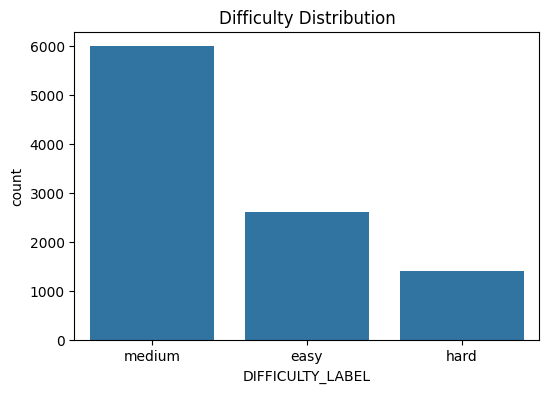

In [261]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["DIFFICULTY_LABEL"])
plt.title("Difficulty Distribution")
plt.show()

## Marks Distribution

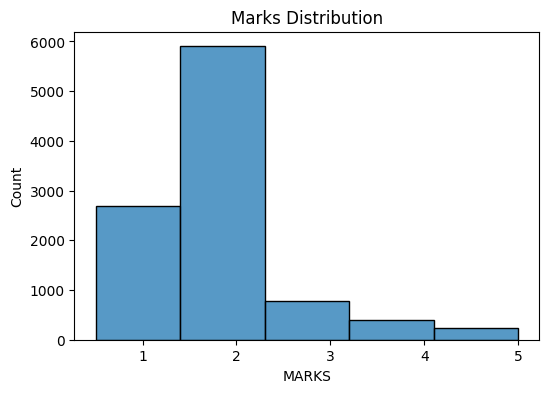

In [262]:
plt.figure(figsize=(6,4))
sns.histplot(df["MARKS"], bins=5)
plt.title("Marks Distribution")
plt.show()

## Topic Distribution

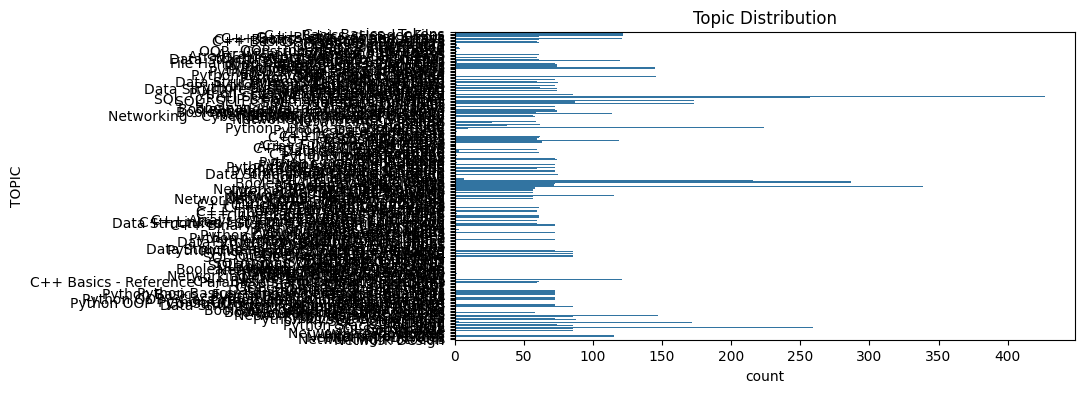

In [263]:
plt.figure(figsize=(8,4))
sns.countplot(y=df["TOPIC"])
plt.title("Topic Distribution")
plt.show()

## Text Preprocessing

In [264]:
df.head()

,YEAR,SECTION,QUESTION_NUMBER,QUESTION_TEXT,QUESTION_TYPE,MARKS,DIFFICULTY_LABEL,TOPIC,ANSWER_TEXT
0,2017,Section A (C++),1a,Write the type of C++ tokens (keywords and use...,Short Answer,2.0,medium,C++ Basics - Tokens,(i) new - Keyword (ii) While - User defined Id...
1,2017,Section A (C++),1b,Anil typed C++ code with errors: (i) Function ...,Very Short Answer,1.0,easy,C++ Basics - Header Files,string.h and iostream.h (or fstream.h or ioman...
2,2017,Section A (C++),1c,Rewrite the following C++ code after removing ...,Short Answer,2.0,medium,C++ Basics - Syntax Errors,Errors: (1) char CH; missing declaration (2) M...
3,2017,Section A (C++),1d,Find and write the output of the following C++...,Short Answer,2.0,medium,C++ Basics - Macros and Arrays,22#40#9#13#
4,2017,Section A (C++),1e,Find and write the output of the following C++...,Short Answer,3.0,medium,C++ Basics - Pointers and Arrays,12*63*73*15*93*10*


In [265]:
df["QUESTION_TEXT"] = df["QUESTION_TEXT"].str.lower()
df["QUESTION_TEXT"] = df["QUESTION_TEXT"].str.replace(r"[^\w\s]", "", regex=True)

In [266]:
df["QUESTION_TEXT"]

,QUESTION_TEXT
0,write the type of c tokens keywords and user d...
1,anil typed c code with errors i function strle...
2,rewrite the following c code after removing an...
3,find and write the output of the following c p...
4,find and write the output of the following c p...
...,...
9995,simplify the boolean expression f ab ab
9996,draw the logic circuit for f ab c
9997,simplify using kmap fabc σ0123
9998,convert the boolean expression to its canonica...


## TF-IDF Vectorization```Explaination add karna hai mujhe```

In [267]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["QUESTION_TEXT"])
y = df["DIFFICULTY_LABEL"]

## Train-Test Split

In [268]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Logistic Regression

In [269]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Evaluate Model

In [270]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        easy       0.99      0.95      0.97       537
        hard       0.99      0.96      0.98       267
      medium       0.97      1.00      0.98      1196

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.98      0.98      0.98      2000



## Confusion Matrix

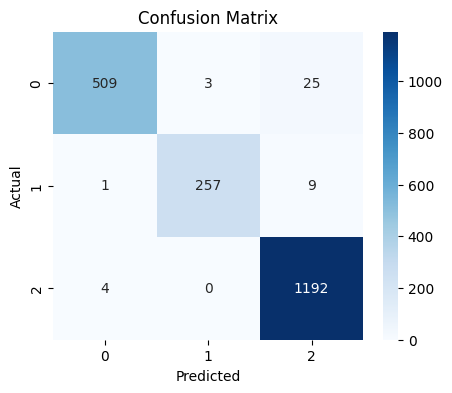

In [271]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Top Important Words (Feature Importance)

In [272]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_words = np.argsort(coefficients)[-15:]
print(feature_names[top_words])

['https' '60' 'wifi' 'distinct' 'query' 'primary' 'network' 'http'
 'relational' 'generate' 'cursor' 'random' 'difference' 'tuple' '80']


### Test on New Question

In [273]:
sample = ["Write a Python Code program to implement binary search."]
sample_vec = vectorizer.transform(sample)
prediction = model.predict(sample_vec)

print("Predicted Difficulty:", prediction[0])

Predicted Difficulty: medium


---
.
.
.

.


---

# After Performing These Set of Operation We have realized Accuracy is too High it means it's memorizing the Data
* 1 mark → easy  
* 5 mark → hard

## We have to Fix this please Welcome
---
**# Method 2**
---

## Remove Leakage Features

In [274]:
df.head()

,YEAR,SECTION,QUESTION_NUMBER,QUESTION_TEXT,QUESTION_TYPE,MARKS,DIFFICULTY_LABEL,TOPIC,ANSWER_TEXT
0,2017,Section A (C++),1a,write the type of c tokens keywords and user d...,Short Answer,2.0,medium,C++ Basics - Tokens,(i) new - Keyword (ii) While - User defined Id...
1,2017,Section A (C++),1b,anil typed c code with errors i function strle...,Very Short Answer,1.0,easy,C++ Basics - Header Files,string.h and iostream.h (or fstream.h or ioman...
2,2017,Section A (C++),1c,rewrite the following c code after removing an...,Short Answer,2.0,medium,C++ Basics - Syntax Errors,Errors: (1) char CH; missing declaration (2) M...
3,2017,Section A (C++),1d,find and write the output of the following c p...,Short Answer,2.0,medium,C++ Basics - Macros and Arrays,22#40#9#13#
4,2017,Section A (C++),1e,find and write the output of the following c p...,Short Answer,3.0,medium,C++ Basics - Pointers and Arrays,12*63*73*15*93*10*


In [275]:
X = vectorizer.fit_transform(df["QUESTION_TEXT"])
y = df["DIFFICULTY_LABEL"]

## Stratified Split (Important)

In [276]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Reduce Model Power Slightly

In [277]:
model = LogisticRegression(
    max_iter=500,
    C=0.5  # stronger regularization
)

## Use Cross Validation (Professional Move)

In [278]:
model_cv = LogisticRegression(max_iter=500, C=0.5)

scores = cross_val_score(model_cv, X, y, cv=5)
print("Cross-val accuracy:", scores.mean())

Cross-val accuracy: 0.7933


## Evaluate Model

In [279]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average="macro"))
print("Recall (macro):", recall_score(y_test, y_pred, average="macro"))
print("F1-score (macro):", f1_score(y_test, y_pred, average="macro"))

Accuracy: 0.45
Precision (macro): 0.3273710514755703
Recall (macro): 0.32775536214447026
F1-score (macro): 0.3274678018682449


In [280]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        easy       0.25      0.25      0.25       522
        hard       0.13      0.12      0.12       281
      medium       0.60      0.61      0.61      1197

    accuracy                           0.45      2000
   macro avg       0.33      0.33      0.33      2000
weighted avg       0.44      0.45      0.45      2000



## Confusion Matrix

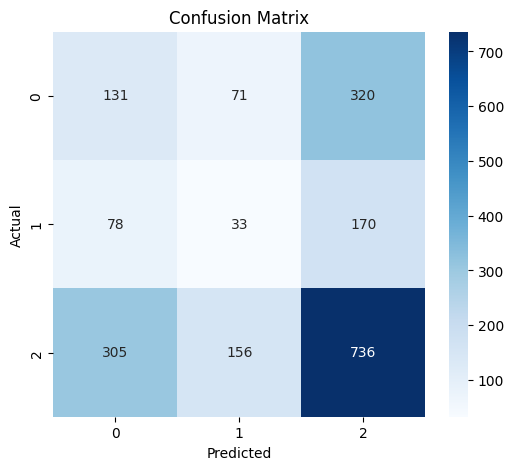

In [281]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


---
# **Method 3**
---

# Let's Use DL Epochs Method

## Add n-grams (Huge Boost)

In [282]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)  # add bigrams
)

## Balance Classes

In [283]:
model = LogisticRegression(
    max_iter=1000,
    C=1,
    class_weight="balanced"
)

## Try LinearSVC (Often Better for Text)

In [284]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train, y_train)

LinearSVC()

## Increase Vocabulary Slightly

In [285]:
max_features=7000

In [286]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

# Detailed Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9865

Classification Report:

              precision    recall  f1-score   support

        easy       0.98      0.98      0.98       522
        hard       1.00      0.98      0.99       281
      medium       0.99      0.99      0.99      1197

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       0.99      0.99      0.99      2000



# Final Method

---
# Method 04
---


# Damm Accuracy is Too Low the Reason is we have only 5 Year of Data here Only we need atleast 30000 Data to achive ~70% accuracy

### But We have an Alternative let's use Topic and Expected answer Lenth also for Train it will ehlp use

In [287]:
df.isna().sum()

,0
YEAR,0
SECTION,0
QUESTION_NUMBER,0
QUESTION_TEXT,0
QUESTION_TYPE,0
MARKS,0
DIFFICULTY_LABEL,0
TOPIC,0
ANSWER_TEXT,0


## Basic Drill clean the Data First

In [288]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text

df["QUESTION_TEXT"] = df["QUESTION_TEXT"].apply(clean_text)
df["TOPIC"] = df["TOPIC"].apply(clean_text)
df["ANSWER_TEXT"] = df["ANSWER_TEXT"].apply(clean_text)

In [289]:
df["COMBINED_TEXT"] = (
    df["QUESTION_TEXT"] + " " +
    df["TOPIC"]
)

In [290]:
X = df['COMBINED_TEXT']
y = df["DIFFICULTY_LABEL"]

## Train-Test Split

In [291]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## TF-IDF

In [292]:
# 2️⃣ Fit vectorizer ONLY on training data

vectorizer = TfidfVectorizer(
    max_features=7000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

## LogisticRegression Model

In [293]:
# 3️⃣ Train model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Evaluate

In [294]:
# 4️⃣ Evaluate

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.985

Classification Report:

              precision    recall  f1-score   support

        easy       0.97      0.98      0.98       522
        hard       0.99      0.98      0.98       281
      medium       0.99      0.99      0.99      1197

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.98      0.99      2000



## Confusion Matrix (Numeric)

In [295]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[ 514    0    8]
 [   3  275    3]
 [  13    3 1181]]


## Confusion Matrix

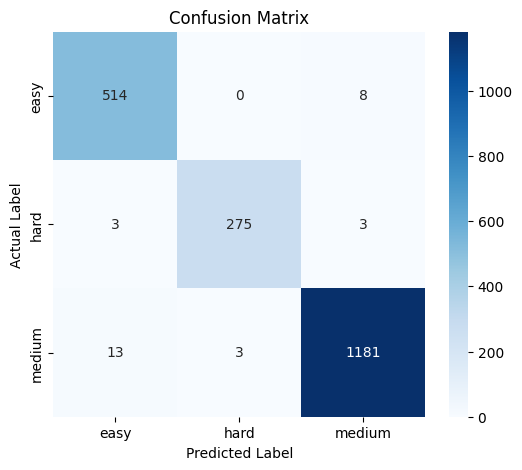

In [296]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Per-Class Accuracy

In [297]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for label, acc in zip(labels, class_accuracy):
    print(f"{label} Accuracy: {round(acc, 3)}")

easy Accuracy: 0.985
hard Accuracy: 0.979
medium Accuracy: 0.987


# Testing

In [298]:
def predict_difficulty(question_text):
    cleaned = question_text.lower()
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)
    return prediction[0]

# Example
print("Predicted Difficulty:",
      predict_difficulty("What is a primary key in a database?"))

Predicted Difficulty: easy


## Here are Some examples
---


**Question:** What is a primary key in a database?

**Question:** Define a list in Python.




**Question:** What is the purpose of the `break` statement in Python?



**Question:** Write a Python program to check whether a number is a palindrome or not.




**Question:** Explain the difference between `WHERE` and `HAVING` clause in SQL with an example.




**Question:** Describe the concept of normalization in DBMS and explain its advantages.


**Question:** Write a function in Python to count the frequency of each element in a list.



**Question:** Design and implement a Python program using file handling to store student records and perform search and update operations.


**Question:** Given two relational tables, write SQL queries to perform INNER JOIN, LEFT JOIN, and RIGHT JOIN, and explain the output with suitable examples.




**Question:** Analyze the time complexity of Binary Search and compare it with Linear Search. Justify with mathematical reasoning and practical scenarios.



# Let's make Model Now :)

In [299]:
import pickle

# Save model
with open("difficulty_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
